In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
train_data = pd.read_csv(r'train.csv')
test_data = pd.read_csv(r'test.csv')

In [8]:
feature = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'HalfBath', 'TotRmsAbvGrd']
X = train_data[feature]
y = train_data['SalePrice']

# Spiting the train data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 96.59,-28610.06, 30474.49, 4632.98, 2707.79]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['GrLivArea','BedroomAbvGr','FullBath','HalfBath','TotRmsAbvGrd']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.9e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [9]:
y_pred = model.predict(X_val)                           #Y prediction
mean_abs_err = mean_absolute_error(y_val, y_pred)       #Mean Absolute Error
mean_sq_err = mean_squared_error(y_val, y_pred)         #Mean Square Error
r2_scr = r2_score(y_val, y_pred)                        #r2 Score

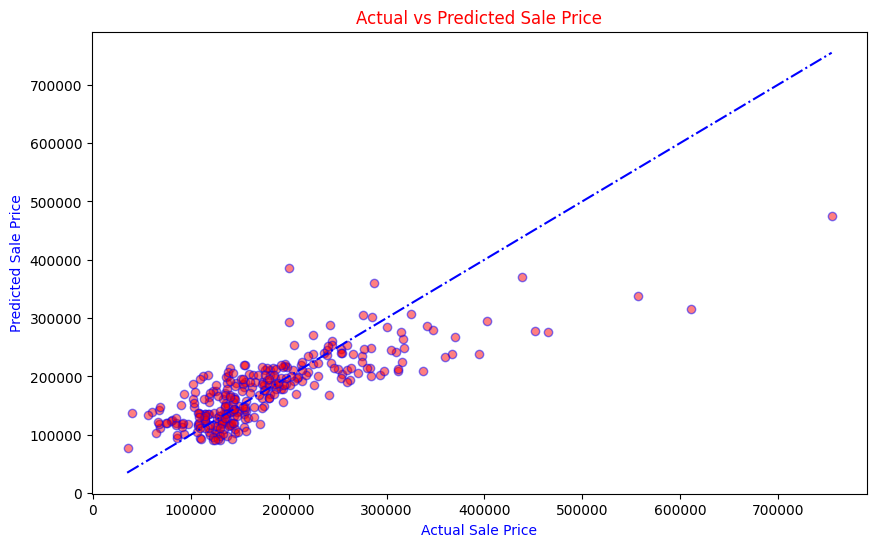

In [10]:
plt.figure(figsize=(10, 6))                             #Ploting Actual vs Predicted Sales Price
plt.scatter(y_val, y_pred, alpha=0.5, color='r', edgecolors='b')
plt.xlabel('Actual Sale Price', color='blue')
plt.ylabel('Predicted Sale Price', color='blue')
plt.title('Actual vs Predicted Sale Price', color='red')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'b-.')
plt.show()

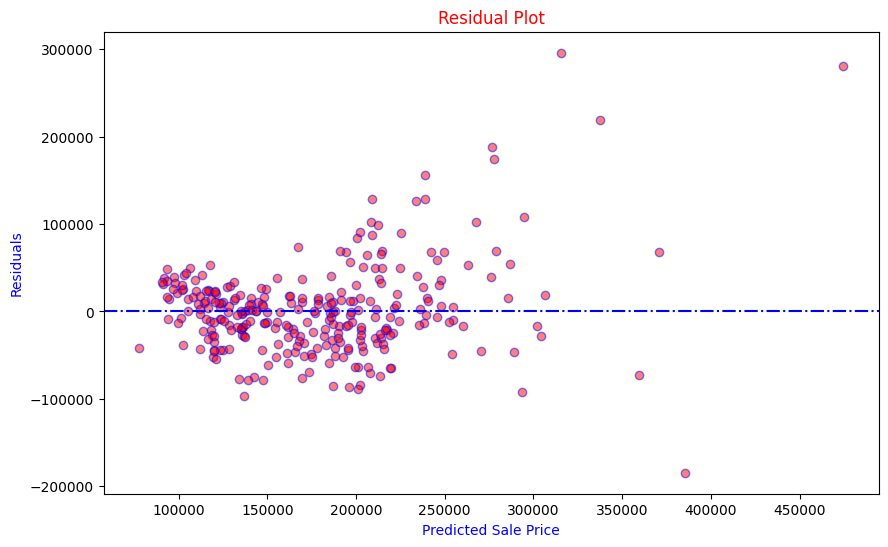

In [11]:
residuals = y_val - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='r', edgecolors='b')
plt.xlabel('Predicted Sale Price', color='blue')
plt.ylabel('Residuals', color='blue')
plt.title('Residual Plot', color='red')
plt.axhline(y=0, color='b', linestyle='-.')
plt.show()

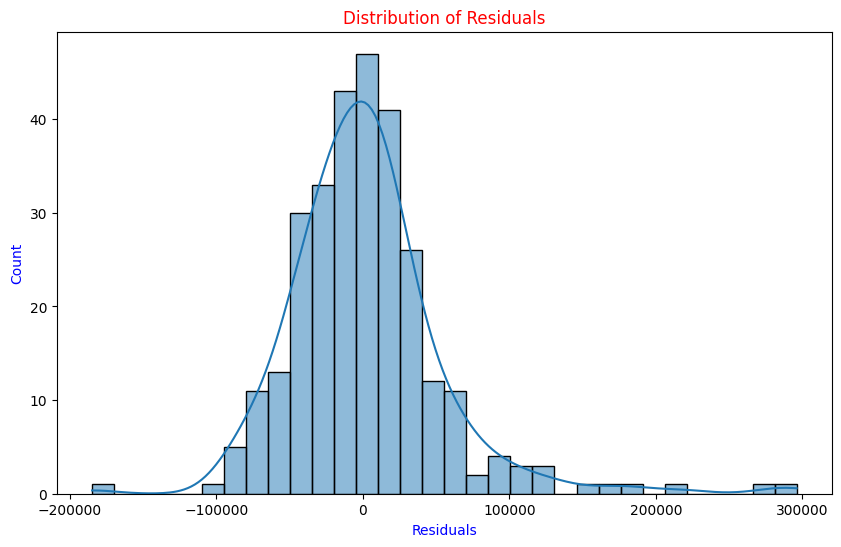

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals', color='b')
plt.ylabel('Count', color='b')
plt.title('Distribution of Residuals', color='r')
plt.show()


<Figure size 1200x800 with 0 Axes>

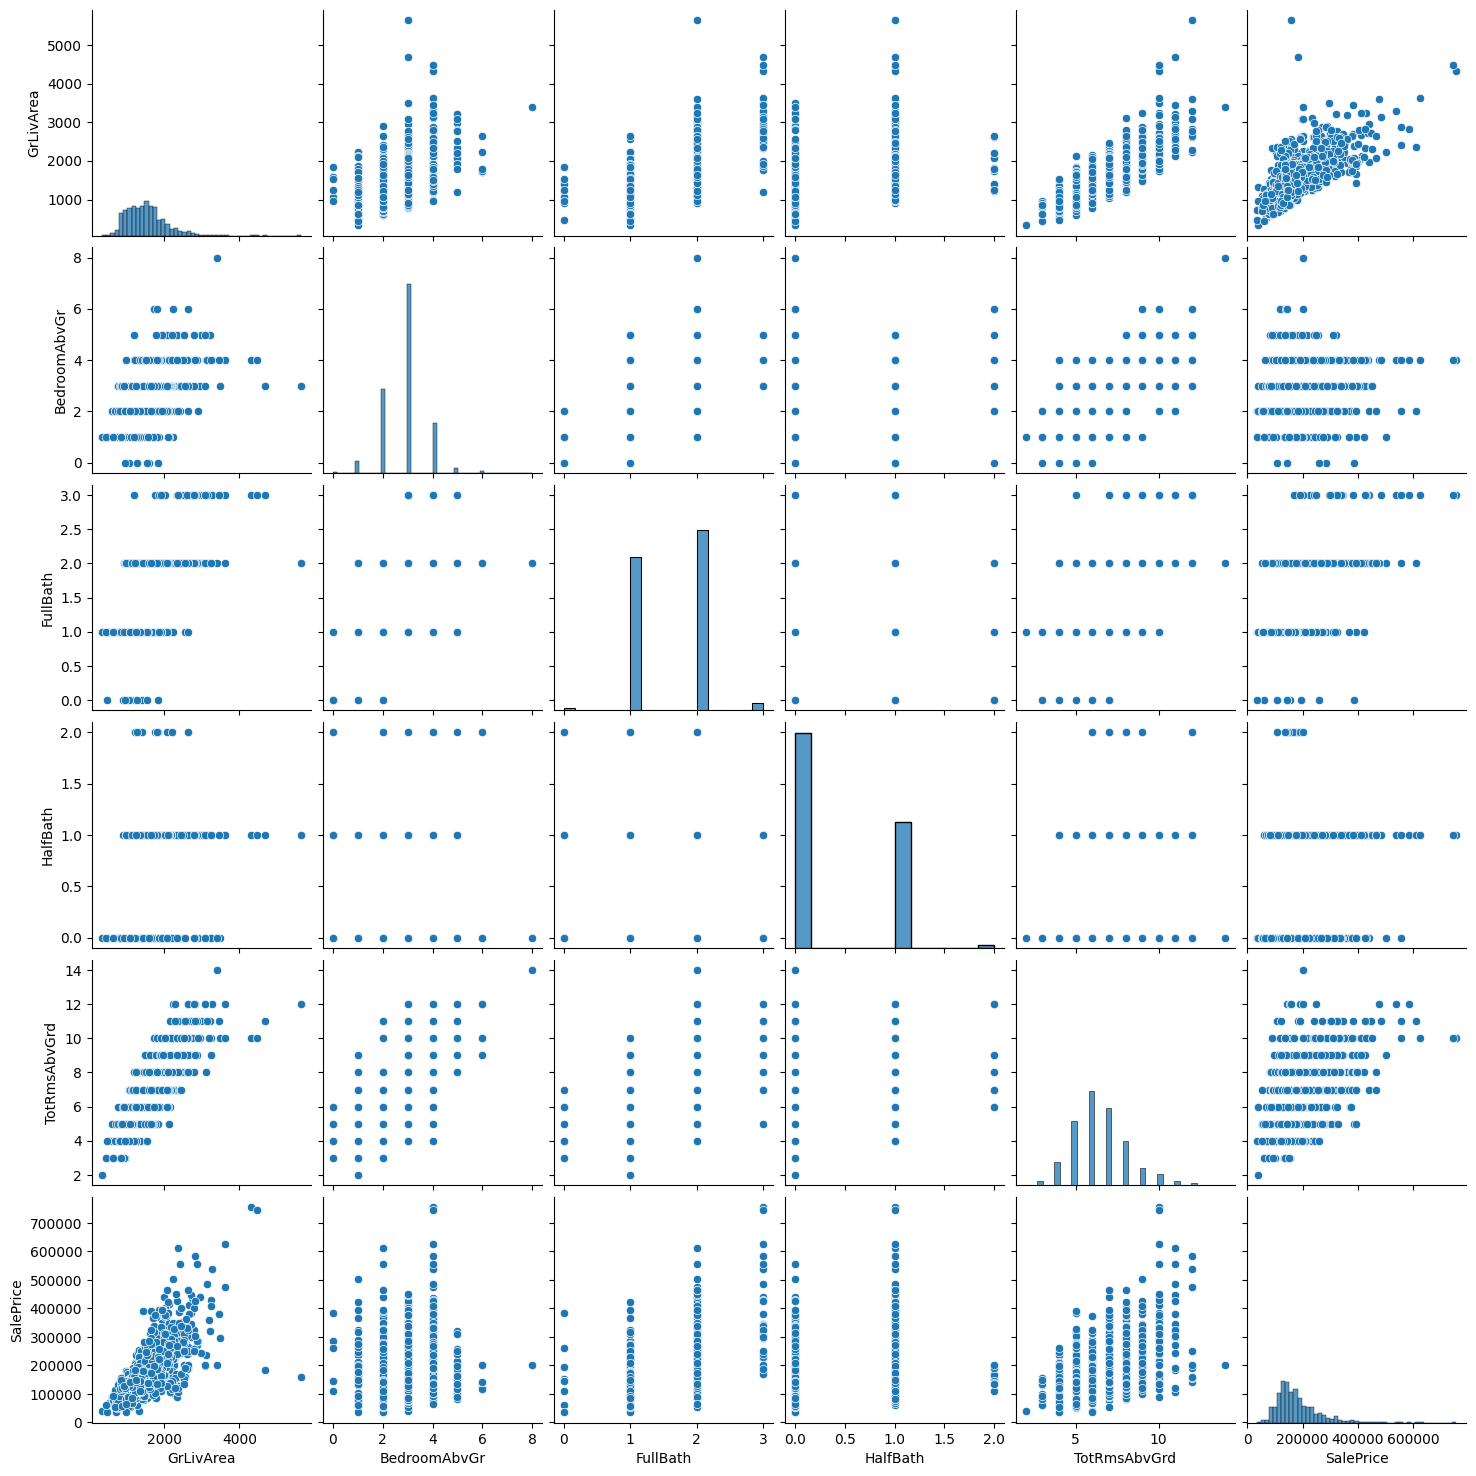

In [13]:
plt.figure(figsize=(12, 8))
sns.pairplot(train_data[feature + ['SalePrice']])
plt.show()

In [14]:
ex_data = {'GrLivArea':[1000],'BedroomAbvGr':[5],'FullBath':[1],'HalfBath':[3],'TotRmsAbvGrd':[4]}
example = pd.DataFrame(ex_data)
example_prediction = model.predict(example)
print(f'Example Prediction: ${example_prediction[0]:,.2f}')

X_test = test_data[feature]
test_predictions = model.predict(X_test)

pred = pd.DataFrame({'Id': test_data['Id'], 'SalePrice': test_predictions})
pred.to_csv('Predictions.csv', index=False)

Example Prediction: $57,750.24
